# Modelling ERBB2 intracellular signaling using CORNETO
In this notebook we use the advanced CARNIVAL implementation available in CORNETO to infer the intracellular signaling network from ERBB2 to TFs to understand how ERBB2 might be signaling inside the heart. We have two networks, one for SHAM conditions (WT sham vs ERBB2-OE sham) and one after MI (WT MI vs ERBB2-OE MI).

- **Parameter Sensitivity**: Alterations in solver settings, threshold values, or choice of prior-knowledge networks can materially affect the inferred network.

- **Data Dependence**: The characteristics of your dataset—experimental design, sample size, preprocessing, and normalization—will directly influence model outputs.

- **Knowledge-Base Limitations**: Underlying pathway repositories may exhibit incomplete coverage and annotation biases.

Each network generated by CARNIVAL should be regarded as a potential, simplified hypothesis of the real signalling.

## Data description
The starting point for analysis is the differentially gene expression results obtained by pyDESeq2. First, collectri enrichment with decoupler is run for two contrasts: WT Sham vs OE Sham, and WT MI vs OE MI. Then, a network is modeled for each one of these contrasts. n=4 for each condition.


In [2]:
import gzip
import os
import shutil
import tempfile
import urllib.request
import pandas as pd

# https://decoupler-py.readthedocs.io
import decoupler as dc
import numpy as np

# https://omnipathdb.org/
import omnipath as op
import liana as li

# Pydeseq for differential expression analysis
#from pydeseq2.dds import DefaultInference, DeseqDataSet
#from pydeseq2.ds import DeseqStats

# https://corneto.org
import corneto as cn
import graphviz
#import networkx as nx

In [3]:
max_time = 500
seeds = [i for i in range(100)] # We will run corneto 100 times with different seeds to get a distribution of solutions and select edges that appear in > 50% of runs.

In [4]:
project_dir = "/mnt/sds-hd/sd22b002/projects/ines/axl_networks/results/osm_lif"
data_dir = os.path.join(project_dir, "pydeseq2")
results_dir = os.path.join(project_dir, "corneto")

## Load the differentially expressed genes and prepare them for enrichment analysis

In [5]:
results_hosm_df = pd.read_csv(f'{data_dir}/GSE185305_OSM_LIF_hosm_vs_control_deseq2.csv', index_col=0)
results_hosm_df.index.name = None
results_hosm_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Pde4b,1784.850318,2.011897,0.113305,17.756413,1.537520e-70,2.542905e-66
Socs3,2718.243670,3.749726,0.212674,17.631300,1.416729e-69,1.171564e-65
Kbtbd11,208.512968,5.127416,0.343852,14.911673,2.767304e-50,1.525615e-46
Hsp25-ps1,2168.833946,2.529907,0.170133,14.870188,5.146880e-50,2.128106e-46
Gm40124,538.062638,2.782339,0.198067,14.047478,7.982667e-45,2.640507e-41
...,...,...,...,...,...,...
Zfp990,3.154037,0.446758,0.937756,0.476412,6.337808e-01,NaN
Zkscan2,2.982153,-0.357602,1.071002,-0.333895,7.384588e-01,NaN
mt-Te,3.208921,-0.066708,1.006172,-0.066299,9.471398e-01,NaN
mt-Tl1,3.113725,1.358741,1.184163,1.147428,2.512050e-01,NaN


In [6]:
results_mosm_df = pd.read_csv(f'{data_dir}/GSE185305_OSM_LIF_mosm_vs_control_deseq2.csv', index_col=0)
results_mosm_df.index.name = None
results_mosm_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Socs3,2718.243670,3.638712,0.212654,17.110932,1.230144e-65,1.988897e-61
Pde4b,1784.850318,1.755033,0.113350,15.483325,4.496182e-54,3.634713e-50
Gm40124,538.062638,2.805171,0.197782,14.183178,1.164507e-45,6.275916e-42
Kbtbd11,208.512968,4.768447,0.344132,13.856456,1.162746e-43,4.699821e-40
Hsp25-ps1,2168.833946,2.228954,0.170176,13.097895,3.385158e-39,1.094625e-35
...,...,...,...,...,...,...
Zkscan2,2.982153,-1.563876,1.164118,-1.343399,1.791428e-01,NaN
mt-Te,3.208921,0.605433,0.945999,0.639993,5.221771e-01,NaN
mt-Tl1,3.113725,1.367653,1.173077,1.165867,2.436681e-01,NaN
mt-Tq,5.217440,0.074946,0.866456,0.086497,9.310714e-01,NaN


In [7]:
results_lif_df = pd.read_csv(f'{data_dir}/GSE185305_OSM_LIF_lif_vs_control_deseq2.csv', index_col=0)
results_lif_df.index.name = None
results_lif_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Hsp25-ps1,2168.833946,1.559706,0.170674,9.138497,6.332602e-20,8.828914e-16
Hspb1,1472.178760,1.860291,0.245669,7.572354,3.665221e-14,1.703350e-10
Fgl2,2054.515251,1.491387,0.195921,7.612191,2.694881e-14,1.703350e-10
Pde4b,1784.850318,0.828940,0.114632,7.231320,4.783221e-13,1.667192e-09
Socs3,2718.243670,1.519192,0.213880,7.103010,1.220685e-12,3.403759e-09
...,...,...,...,...,...,...
mt-Tl1,3.113725,1.304320,1.184608,1.101057,2.708720e-01,NaN
mt-Tq,5.217440,0.077176,0.872735,0.088430,9.295348e-01,NaN
mt-Ts1,9.303629,0.729224,0.877696,0.830839,4.060646e-01,NaN
mt-Tt,6.932592,0.909663,0.804581,1.130605,2.582213e-01,NaN


In [8]:
# Translate to human for compatibilities downstream
mouse_genes = list(set(results_hosm_df.index).union(set(results_mosm_df.index)).union(set(results_lif_df.index)))

# Translate to human
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                  min_evidence=3 # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                 )
map_df = map_df[map_df['mouse_symbol'].isin(mouse_genes)]

# Clean up: remove genes without an ortholog in human
map_df = map_df[map_df['human_symbol'] != '-']

# Clean up: keep unique human genes (remove all human duplicated symbols to keep 1:1 orthologs)
map_df = map_df[~map_df.duplicated(subset='human_symbol', keep=False)]

map_df

/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/liana/resource/_orthology.py:278: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,human_symbol,mouse_symbol
780,A2M,A2m
792,A3GALT2,A3galt2
793,A4GALT,A4galt
795,AAAS,Aaas
796,AACS,Aacs
...,...,...
68071,ZXDC,Zxdc
68075,ZYG11B,Zyg11b
68077,ZYX,Zyx
68078,ZZEF1,Zzef1


In [9]:
# Check number of shared genes between results_mosm_df and map_df
shared_genes = set(results_mosm_df.index).intersection(set(map_df['mouse_symbol']))
print(f"Number of shared genes between results_mosm_df and map_df: {len(shared_genes)}")

Number of shared genes between results_mosm_df and map_df: 12589


In [10]:
# Check number of shared genes between results_hosm_df and map_df
shared_genes = set(results_hosm_df.index).intersection(set(map_df['mouse_symbol']))
print(f"Number of shared genes between results_hosm_df and map_df: {len(shared_genes)}")

Number of shared genes between results_hosm_df and map_df: 12589


In [11]:
# Check number of shared genes between results_lif_df and map_df
shared_genes = set(results_lif_df.index).intersection(set(map_df['mouse_symbol']))
print(f"Number of shared genes between results_lif_df and map_df: {len(shared_genes)}")

Number of shared genes between results_lif_df and map_df: 12589


In [12]:
results_hosm_df_human = (
    results_hosm_df
    .merge(map_df[['mouse_symbol', 'human_symbol']], left_index=True, right_on='mouse_symbol', how='inner')
    .set_index('human_symbol')
    .drop(columns='mouse_symbol')
)
results_hosm_df_human.index.name = None
results_hosm_df_human


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
PDE4B,1784.850318,2.011897,0.113305,17.756413,1.537520e-70,2.542905e-66
SOCS3,2718.243670,3.749726,0.212674,17.631300,1.416729e-69,1.171564e-65
KBTBD11,208.512968,5.127416,0.343852,14.911673,2.767304e-50,1.525615e-46
SPTA1,306.331476,-3.113029,0.224497,-13.866716,1.007866e-43,2.778184e-40
RNF122,181.002124,2.809482,0.216762,12.961118,2.032621e-38,4.802503e-35
...,...,...,...,...,...,...
ZNF239,2.703256,0.920307,1.330573,0.691662,4.891494e-01,NaN
ZNF580,4.223474,0.325975,0.834139,0.390793,6.959505e-01,NaN
ZFP69,2.670145,1.026751,1.050689,0.977217,3.284620e-01,NaN
ZNF853,2.937536,-0.673105,0.986457,-0.682346,4.950202e-01,NaN


In [13]:
results_mosm_df_human = (
    results_mosm_df
    .merge(map_df[['mouse_symbol', 'human_symbol']], left_index=True, right_on='mouse_symbol', how='inner')
    .set_index('human_symbol')
    .drop(columns='mouse_symbol')
)
results_mosm_df_human.index.name = None
results_mosm_df_human

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
SOCS3,2718.243670,3.638712,0.212654,17.110932,1.230144e-65,1.988897e-61
PDE4B,1784.850318,1.755033,0.113350,15.483325,4.496182e-54,3.634713e-50
KBTBD11,208.512968,4.768447,0.344132,13.856456,1.162746e-43,4.699821e-40
SLC39A14,1713.748517,1.232913,0.095302,12.936953,2.784573e-38,7.503497e-35
RNF122,181.002124,2.763734,0.216227,12.781626,2.076818e-37,4.796856e-34
...,...,...,...,...,...,...
ZNF239,2.703256,1.367717,1.295028,1.056129,2.909094e-01,NaN
ZNF580,4.223474,-0.088828,0.846325,-0.104957,9.164097e-01,NaN
ZFP69,2.670145,-0.305188,1.136829,-0.268455,7.883490e-01,NaN
ZNF853,2.937536,-1.914814,1.116900,-1.714400,8.645527e-02,NaN


In [14]:
results_lif_df_human = (
    results_lif_df
    .merge(map_df[['mouse_symbol', 'human_symbol']], left_index=True, right_on='mouse_symbol', how='inner')
    .set_index('human_symbol')
    .drop(columns='mouse_symbol')
)
results_lif_df_human.index.name = None
results_lif_df_human

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
HSPB1,1472.178760,1.860291,0.245669,7.572354,3.665221e-14,1.703350e-10
FGL2,2054.515251,1.491387,0.195921,7.612191,2.694881e-14,1.703350e-10
PDE4B,1784.850318,0.828940,0.114632,7.231320,4.783221e-13,1.667192e-09
SOCS3,2718.243670,1.519192,0.213880,7.103010,1.220685e-12,3.403759e-09
KBTBD11,208.512968,2.229644,0.358477,6.219764,4.979047e-10,1.156965e-06
...,...,...,...,...,...,...
ZNF853,2.937536,-0.235031,0.947671,-0.248009,8.041276e-01,NaN
ZFYVE28,10.620483,-1.761273,0.715830,-2.460463,1.387579e-02,NaN
ZKSCAN2,2.982153,-0.719233,1.094422,-0.657180,5.110650e-01,NaN
ZMYND15,10.613416,-0.034775,0.748014,-0.046489,9.629203e-01,NaN


In [15]:
data_hosm = results_hosm_df_human[["stat"]].T.rename(index={"stat": "hOSM.vs.Control"})
data_hosm

,PDE4B,SOCS3,KBTBD11,SPTA1,RNF122,SLC39A14,HIPK1,SLC35G2,HSPB1,ANGPTL4,...,ZAN,ZCCHC12,ZCCHC18,ZCWPW2,ZDHHC23,ZNF239,ZNF580,ZFP69,ZNF853,ZKSCAN2
hOSM.vs.Control,17.756413,17.6313,14.911673,-13.866716,12.961118,12.942087,12.623895,12.600968,12.502326,12.345812,...,0.582932,0.309073,0.309073,-0.587627,0.641986,0.691662,0.390793,0.977217,-0.682346,-0.333895


In [16]:
data_mosm = results_mosm_df_human[["stat"]].T.rename(index={"stat": "mOSM.vs.Control"})
data_mosm

,SOCS3,PDE4B,KBTBD11,SLC39A14,RNF122,SPTA1,ANGPTL4,C4orf54,SLC35G2,STEAP4,...,ZAN,ZCCHC12,ZCCHC18,ZCWPW2,ZDHHC23,ZNF239,ZNF580,ZFP69,ZNF853,ZKSCAN2
mOSM.vs.Control,17.110932,15.483325,13.856456,12.936953,12.781626,-12.161397,11.69153,11.137717,10.952457,10.755497,...,0.615762,0.256379,0.256379,-0.606949,0.746548,1.056129,-0.104957,-0.268455,-1.7144,-1.343399


In [17]:
data_lif = results_lif_df_human[["stat"]].T.rename(index={"stat": "mLIF.vs.Control"})
data_lif

,HSPB1,FGL2,PDE4B,SOCS3,KBTBD11,ANGPTL4,MAPKAPK2,STEAP4,MT1A,MT1B,...,ZNF250,ZFP69,ZNF707,ZNF786,ZNF791,ZNF853,ZFYVE28,ZKSCAN2,ZMYND15,ZPBP
mLIF.vs.Control,7.572354,7.612191,7.23132,7.10301,6.219764,5.650906,5.514021,5.384577,5.238488,5.238488,...,-0.385767,0.057032,-1.681133,-0.294431,0.065864,-0.248009,-2.460463,-0.65718,-0.046489,-0.0023


## Estimation of Transcription Factor activities with Deocupler and CollecTRI

In [18]:
# Retrieve CollecTRI gene regulatory network (through Omnipath).
# These are regulons that we will use for enrichment tests
# to infer TF activities
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [19]:
# Run
tf_acts_hosm, tf_padj_hosm = dc.mt.ulm(data=data_hosm, net=collectri)

# Save results as df
tf_results_hosm = pd.DataFrame({
    'TF': tf_acts_hosm.columns,
    'activity': tf_acts_hosm.iloc[0].values,
    'padj': tf_padj_hosm.iloc[0].values,
})

tf_results_hosm.to_csv(f'{results_dir}/hOSM_vs_Control_collectri_results.csv', index=False)

# Filter by sign padj
msk = (tf_padj_hosm.T < 0.05).iloc[:, 0]
tf_acts_hosm = tf_acts_hosm.loc[:, msk]

tf_acts_hosm

,AIP,AP1,APEX1,CREB1,E2F1,FOXF2,GATA4,HSF2,HSF4,JUN,...,SRF,STAT1,STAT3,STAT4,TEAD1,THAP11,TRPS1,ZEB1,ZFP42,ZNF804A
hOSM.vs.Control,3.573683,3.599462,3.071323,3.338095,-3.418708,-4.685184,-3.120858,5.193951,5.090745,5.196208,...,-4.635738,4.959686,4.356385,-4.187014,-3.361875,3.599215,-3.504854,3.300852,3.670121,3.41745


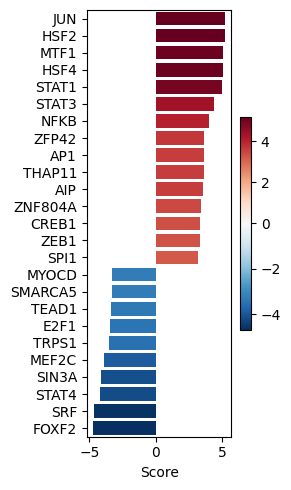

In [20]:
dc.pl.barplot(data=tf_acts_hosm, name="hOSM.vs.Control", top=25, figsize=(3, 5))

In [21]:
# Run
tf_acts_mosm, tf_padj_mosm = dc.mt.ulm(data=data_mosm, net=collectri)

# Save results as df
tf_results_mosm = pd.DataFrame({
    'TF': tf_acts_mosm.columns,
    'activity': tf_acts_mosm.iloc[0].values,
    'padj': tf_padj_mosm.iloc[0].values,
})

tf_results_mosm.to_csv(f'{results_dir}/mOSM_vs_Control_collectri_results.csv', index=False)

# Filter by sign padj
msk = (tf_padj_mosm.T < 0.05).iloc[:, 0]
tf_acts_mosm = tf_acts_mosm.loc[:, msk]

tf_acts_mosm

,AIP,AP1,APEX1,ATF2,CREB1,E2F1,ETV3,FOXF2,GATA4,HIVEP1,...,STAT1,STAT3,STAT4,TEAD1,THAP11,TRPS1,ZEB1,ZFP42,ZNF384,ZNF804A
mOSM.vs.Control,3.447375,4.749779,3.559894,3.132699,4.919283,-3.140809,-3.383164,-4.522622,-3.049357,-3.212432,...,5.305032,5.01592,-3.944684,-3.491411,4.286547,-4.005458,3.334582,4.084992,3.167542,3.338184


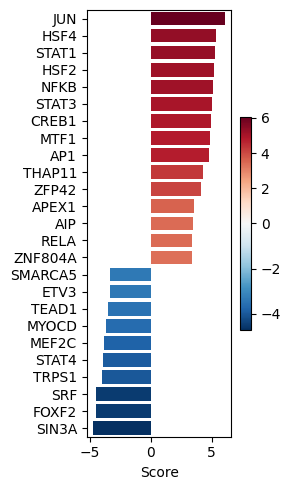

In [22]:
dc.pl.barplot(data=tf_acts_mosm, name="mOSM.vs.Control", top=25, figsize=(3, 5))

In [23]:
# Run
tf_acts_lif, tf_padj_lif = dc.mt.ulm(data=data_lif, net=collectri)

# Save results as df
tf_results_lif = pd.DataFrame({
    'TF': tf_acts_lif.columns,
    'activity': tf_acts_lif.iloc[0].values,
    'padj': tf_padj_lif.iloc[0].values,
})

tf_results_lif.to_csv(f'{results_dir}/mLIF_vs_Control_collectri_results.csv', index=False)

# Filter by sign padj
msk = (tf_padj_lif.T < 0.05).iloc[:, 0]
tf_acts_lif = tf_acts_lif.loc[:, msk]

tf_acts_lif

,FOXF2,HSF2,HSF4,JUN,MEF2C,MTF1,STAT1
mLIF.vs.Control,-4.434383,4.443369,4.207981,3.884704,-4.053263,4.52117,5.380987


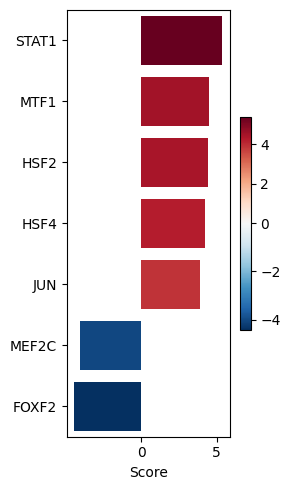

In [24]:
dc.pl.barplot(data=tf_acts_lif, name="mLIF.vs.Control", top=25, figsize=(3, 5))

## Inferring intracellular signaling networks with CARNIVAL and CORNETO

CORNETO is a unified framework for knowledge-driven network inference. It includes a very flexible implementation of CARNIVAL that expands its original capabilities. We will see how to use it under different assumptions to extract a network from a prior knowledge network and a set of potential receptors + our estimated TFs

Installed version: v1.0.0b7
Available backends: CVXPY v1.8.2, PICOS v2.6.2
Default backend (corneto.opt): CVXPY
Installed solvers: CLARABEL, CVXOPT, GLPK, GLPK_MI, GUROBI, HIGHS, OSQP, SCIP, SCIPY, SCS
Plot backend (default): auto -> graphviz
Available plot backends: graphviz v0.21; networkx v3.6.1+mpl v3.10.8; graphviz-wasm
Installed path: /home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto
Repository: https://github.com/saezlab/corneto
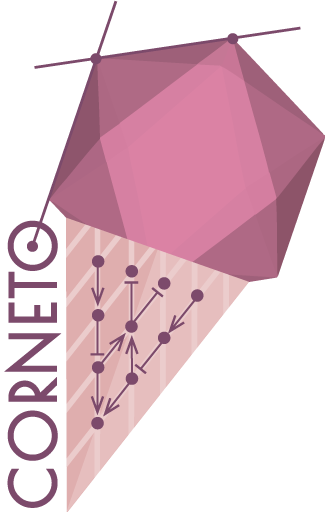

In [25]:
cn.info()

In [26]:
from corneto.methods.future import CarnivalFlow

CarnivalFlow.show_references()

- Pablo Rodriguez-Mier, Martin Garrido-Rodriguez, Attila Gabor, Julio Saez-Rodriguez. Unified knowledge-driven network inference from omics data. bioRxiv, pp. 10 (2024).
 - Anika Liu, Panuwat Trairatphisan, Enio Gjerga, Athanasios Didangelos, Jonathan Barratt, Julio Saez-Rodriguez. From expression footprints to causal pathways: contextualizing large signaling networks with CARNIVAL. NPJ systems biology and applications, Vol. 5, No. 1, pp. 40 (2019).

In [27]:
# We get only interactions from SIGNOR http://signor.uniroma2.it/
pkn = op.interactions.OmniPath.get(databases=["SIGNOR"], genesymbols=True)
pkn = pkn[pkn.consensus_direction == True]
pkn.head()

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,sources,references,curation_effort,n_sources,n_primary_sources,n_references,references_stripped
0,Q13976,Q13507,PRKG1,TRPC3,True,False,True,True,False,True,PhosphoSite_MIMP;MIMP;HPRD_MIMP;PhosphoSite_no...,SIGNOR:14983059;HPRD:14983059;KEA:14983059;Pro...,7,15,8,2,14983059;16331690
1,P06241,Q9Y210,FYN,TRPC6,True,True,False,True,True,False,TRIP;PhosphoPoint;SIGNOR;HPRD;SPIKE_LC,TRIP:14761972;HPRD:14761972;SIGNOR:21471003;SP...,4,5,4,3,14761972;16713569;21471003
2,Q13976,Q9Y210,PRKG1,TRPC6,True,False,True,True,False,True,Sparser_ProtMapper;phosphoELM_MIMP;PhosphoSite...,TRIP:18617565;SIGNOR:19961855;ProtMapper:21402...,4,11,5,4,18617565;19961855;21402151;24740790
3,P12931,Q9Y210,SRC,TRPC6,True,True,False,True,True,False,TRIP;PhosphoPoint;SIGNOR;ProtMapper;HPRD;REACH...,TRIP:14761972;HPRD:14761972;SIGNOR:21471003;Pr...,4,6,5,2,14761972;21471003
4,Q13976,Q9HCX4,PRKG1,TRPC7,True,True,False,True,True,False,iPTMnet;TRIP;SIGNOR;ProtMapper;SIGNOR_ProtMapper,SIGNOR:21402151;ProtMapper:21402151;TRIP:21402151,3,5,4,1,21402151


In [28]:
pkn["interaction"] = pkn["is_stimulation"].astype(int) - pkn["is_inhibition"].astype(int)
sel_pkn = pkn[["source_genesymbol", "interaction", "target_genesymbol"]]
sel_pkn

,source_genesymbol,interaction,target_genesymbol
0,PRKG1,-1,TRPC3
1,FYN,1,TRPC6
2,PRKG1,-1,TRPC6
3,SRC,1,TRPC6
4,PRKG1,1,TRPC7
...,...,...,...
65526,LPAR5,1,GNA13
65527,PRKCA,-1,ITPKB
65528,UBXN1,1,NGLY1
65529,CCNC,-1,NOTCH1


In [29]:
# We create the CORNETO graph by importing the edges and interaction
from corneto.io import load_graph_from_sif_tuples

G = load_graph_from_sif_tuples([(r[0], r[1], r[2]) for _, r in sel_pkn.iterrows() if r[1] != 0])
G.shape

/tmp/ipykernel_3173226/1534210904.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


(6092, 63820)

## hOSM network

In [30]:
# As measurements, we take the estimated TFs, we will filter out TFs with p-val > 0.001
significant_tfs_hosm = tf_acts_hosm[tf_padj_hosm <= 0.05].T.dropna().sort_values(by="hOSM.vs.Control", ascending=False)
significant_tfs_hosm

,hOSM.vs.Control
JUN,5.196208
HSF2,5.193951
MTF1,5.096062
HSF4,5.090745
STAT1,4.959686
STAT3,4.356385
NFKB,4.027668
ZFP42,3.670121
AP1,3.599462
THAP11,3.599215


In [31]:
# We keep only the ones in the PKN graph
measurements_hosm = significant_tfs_hosm.loc[significant_tfs_hosm.index.intersection(G.V)].to_dict()["hOSM.vs.Control"]
measurements_hosm

{'JUN': 5.1962080486574695,
 'HSF2': 5.193950576719463,
 'MTF1': 5.096062365572499,
 'HSF4': 5.090744955184348,
 'STAT1': 4.959686137615967,
 'STAT3': 4.356385414856813,
 'ZFP42': 3.6701209557834975,
 'ZNF804A': 3.4174503005211787,
 'CREB1': 3.3380952114306472,
 'ZEB1': 3.300851794939295,
 'SPI1': 3.198944928505441,
 'APEX1': 3.0713225148484944,
 'GATA4': -3.120858383212508,
 'KDM5B': -3.1829953069484453,
 'MYOCD': -3.283567893798584,
 'TEAD1': -3.36187542189483,
 'E2F1': -3.4187081552518883,
 'TRPS1': -3.5048543548413145,
 'MEF2C': -3.896594037628032,
 'SIN3A': -4.112784714153529,
 'STAT4': -4.187014343272331,
 'SRF': -4.635737579468398,
 'FOXF2': -4.685183533834411}

In [32]:
# Check that OSM is in graph
"OSM" in G.V

True

In [33]:
# Here we pass the receptors. We're going to use OSM as receptor. We set it as active because the treatment is OSM activation, and OSM is overexpressed in the treatment group.
inputs = {"OSM": 1}  # 1=up, -1=down
inputs

{'OSM': 1}

In [34]:
# Create the dataset in standard format
carnival_data_hosm = dict()
for inp, v in inputs.items():
    carnival_data_hosm[inp] = dict(value=v, role="input", mapping="vertex")
for out, v in measurements_hosm.items():
    carnival_data_hosm[out] = dict(value=v, role="output", mapping="vertex")
data_hosm = cn.Data.from_cdict({"sample1": carnival_data_hosm})
data_hosm

Data(n_samples=1, n_feats=[24])

### CARNIVAL
We will use now the CARNIVAL, as implemented with CORNETO, with a penalty to regularize the solution. For hypothesis exploration, we can try different values and manually inspect the solutions. We are going to penalize also the selection of indirect rules, to simplify the solution. These rules are:
- A -> B in the PKN, and we observe B is downregulated, we explain it with downregulation of its upstream gene A
- A -| B in the PKN, and we observe B is upregulated, we explain it with downregulation of A

In [35]:
carnival = CarnivalFlow(lambda_reg=1.0, indirect_rule_penalty=10)
P = carnival.build(G, data_hosm)
P.expr

Unreachable vertices for sample: 0


{'edge_inhibits': edge_inhibits: Variable((5208, 1), edge_inhibits, boolean=True),
 'edge_activates': edge_activates: Variable((5208, 1), edge_activates, boolean=True),
 '_dag_layer': _dag_layer: Variable((1277, 1), _dag_layer),
 '_flow': _flow: Variable((5208,), _flow),
 'const0x12da1825e7a04286': const0x12da1825e7a04286: Constant(CONSTANT, NONNEGATIVE, (1277, 5208)),
 'const0x1e57fdbd8fad06c0': const0x1e57fdbd8fad06c0: Constant(CONSTANT, NONNEGATIVE, (1277, 5208)),
 'flow': _flow: Variable((5208,), _flow),
 'vertex_value': Expression(AFFINE, UNKNOWN, (1277, 1)),
 'vertex_activated': Expression(AFFINE, NONNEGATIVE, (1277, 1)),
 'vertex_inhibited': Expression(AFFINE, NONNEGATIVE, (1277, 1)),
 'edge_value': Expression(AFFINE, UNKNOWN, (5208, 1)),
 'edge_has_signal': Expression(AFFINE, NONNEGATIVE, (5208, 1)),
 'vertex_max_depth': _dag_layer: Variable((1277, 1), _dag_layer)}

In [36]:
results = {}

# We run corneto 100 times, each with a different seed. Then we will select edges that appear in > 50% of runs.
for seed in seeds:
    print(f"Running corneto with seed {seed}...")
    P.solve(solver="highs", max_seconds=60, verbosity=0, random_seed=seed);
    
    for o in P.objectives:
        print(o.name, "->", o.value)
    
    # Extract the selected edges
    sol_edges = np.flatnonzero(np.abs(P.expr.edge_value.value) > 0.5)
    carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    dot_source = carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    # inject smaller font size
    dot_source = dot_source.replace(
        'node [fixedsize="true"];',
        'node [fixedsize="true", fontsize="8"]; edge [fontsize="8"];'
    )

    # display(graphviz.Source(dot_source))

    # Extracting the solution graph
    G_sol = carnival.processed_graph.edge_subgraph(sol_edges)
    print(G_sol.shape)


    # Get node df of final filtered graph solution
    node_df = pd.DataFrame(P.expr.vertex_value.value, index=carnival.processed_graph.V, columns=["node_activity"])
    node_df_filt = node_df.loc[node_df.index.isin(G_sol.V)]
    node_df_filt = node_df_filt.reset_index(names='gene_symbol')

    # Get edge df of final filtered graph solution, reshaped to From, To, edge_activity
    edge_df = pd.DataFrame(P.expr.edge_value.value, index=carnival.processed_graph.E, columns=["edge_activity"])
    edge_df_filtered = edge_df.loc[edge_df.index.isin(G_sol.E)].reset_index()
    edge_df_filtered.columns = ["From", "To", "edge_activity"]

    # Save into dictionary
    results[seed] = {"nodes": node_df, "edges": edge_df}


Running corneto with seed 0...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 72.88152940074649
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 1.0
(1, 1)
Running corneto with seed 1...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 21.951687421612654
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 32.0
(32, 32)
Running corneto with seed 2...


...

/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 21.951687421612654
penalty_indirect_rules_0 -> [1.]
regularization_edge_has_signal -> 34.0
(34, 34)
Running corneto with seed 98...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 21.951687421612654
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 30.0
(30, 30)
Running corneto with seed 99...
error_sample1_0 -> 31.725285985511622
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 25.0
(25, 25)


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


In [41]:
n_runs = len(results)

def format_side(side):
    """Turn a tuple of node names into a clean comma-joined string, or '' if empty."""
    if not side:
        return ""
    return ",".join(side)

def get_nodes(side):
    """Flatten a tuple of node names into individual node strings."""
    return list(side) if side else []

# Long-format edge table across all runs
edge_frames = []
for seed, res in results.items():
    ed = res["edges"].copy()
    ed["seed"] = seed
    ed["edge"] = ed.index
    edge_frames.append(ed.reset_index(drop=True))

edges_long = pd.concat(edge_frames, ignore_index=True)
edges_long["present"] = edges_long["edge_activity"].abs() > 0.5

# Frequency and mean activity per edge
edge_summary = (
    edges_long.groupby("edge")
    .agg(
        frequency=("present", "mean"),
        mean_activity=("edge_activity", "mean"),
        n_present=("present", "sum"),
    )
    .reset_index()
)

# Keep only edges present in >50% of runs
results_edge_df = (
    edge_summary[edge_summary["frequency"] > 0.5]
    .sort_values("frequency", ascending=False)
    .reset_index(drop=True)
)

# Add readable From/To columns
results_edge_df["From"] = results_edge_df["edge"].apply(lambda e: format_side(e[0]))
results_edge_df["To"] = results_edge_df["edge"].apply(lambda e: format_side(e[1]))
results_edge_df = results_edge_df.drop(columns="edge")[
    ["From", "To", "frequency", "mean_activity", "n_present"]
]

# Get the set of nodes involved in these edges (flattening both sides)
involved_nodes = set()
for e in edge_summary.loc[edge_summary["frequency"] > 0.5, "edge"]:
    involved_nodes.update(get_nodes(e[0]))
    involved_nodes.update(get_nodes(e[1]))

# Long-format node table, averaged over all 100 runs
node_frames = []
for seed, res in results.items():
    nd = res["nodes"].copy()
    nd["seed"] = seed
    nd["node"] = nd.index
    node_frames.append(nd.reset_index(drop=True))

nodes_long = pd.concat(node_frames, ignore_index=True)

node_summary = (
    nodes_long.groupby("node")["node_activity"]
    .mean()
    .reset_index()
    .rename(columns={"node_activity": "mean_activity"})
)

# Filter to nodes involved in the selected edges
results_node_df = node_summary[node_summary["node"].isin(involved_nodes)].reset_index(drop=True)
results_node_df = results_node_df.rename(columns={"node": "Node"})

In [42]:
results_edge_df.to_csv(f"{results_dir}/hOSM_vs_Control_corneto_edges.csv", index=False)
results_node_df.to_csv(f"{results_dir}/hOSM_vs_Control_corneto_nodes.csv", index=False)

In [43]:
results_node_df

,Node,mean_activity
0,AEBP2_EED_EZH2_RBBP4_SUZ12,0.63
1,ATM,0.56
2,E2F1,-0.56
3,HIPK2,0.55
4,HSF4,0.70
5,IL6ST,0.71
6,JUN,0.71
7,KDM5B,-0.71
8,MAP2K6,0.70
9,MAP3K1,0.64


In [ ]:
# Annotate node df with log2FC results from DESeq2
results_node_df = results_node_df.merge(
    results_hosm_df_human[["log2FoldChange", "padj"]],
    left_on="Node",
    right_index=True,
    how="left",
)
results_node_df = results_node_df.rename(columns={'log2FoldChange': 'deseq2.log2FC', 'padj': 'deseq2.padj', 'mean_activity': 'corneto_node_mean_activity'})

# Annotate node df with TF activity predictions from decoupler
results_node_df = results_node_df.merge(
    tf_results_hosm.rename(columns={"activity": "collectri.activity", "padj": "collectri.padj"}),
    left_on="Node",
    right_on="TF",
    how="left",
)
results_node_df = results_node_df.drop(columns="TF")
results_node_df.to_csv(f"{results_dir}/hOSM_vs_Control_corneto_nodes_annotated.csv", index=False)
results_node_df

,Node,corneto_node_mean_activity,deseq2.log2FC,deseq2.padj,collectri.activity,collectri.padj
0,AEBP2_EED_EZH2_RBBP4_SUZ12,0.63,NaN,NaN,NaN,NaN
1,ATM,0.56,NaN,NaN,NaN,NaN
2,E2F1,-0.56,NaN,NaN,-3.418708,0.021892
3,HIPK2,0.55,NaN,NaN,-0.264665,0.950530
4,HSF4,0.70,NaN,NaN,5.090745,0.000059
5,IL6ST,0.71,NaN,NaN,NaN,NaN
6,JUN,0.71,NaN,NaN,5.196208,0.000059
7,KDM5B,-0.71,NaN,NaN,-3.182995,0.036864
8,MAP2K6,0.70,NaN,NaN,NaN,NaN
9,MAP3K1,0.64,NaN,NaN,NaN,NaN


## mOSM network

In [45]:
# As measurements, we take the estimated TFs, we will filter out TFs with p-val > 0.001
significant_tfs_mosm = tf_acts_mosm[tf_padj_mosm <= 0.05].T.dropna().sort_values(by="mOSM.vs.Control", ascending=False)
significant_tfs_mosm

,mOSM.vs.Control
JUN,6.072403
HSF4,5.326287
STAT1,5.305032
HSF2,5.162898
NFKB,5.141402
STAT3,5.015920
CREB1,4.919283
MTF1,4.831795
AP1,4.749779
THAP11,4.286547


In [46]:
# We keep only the ones in the PKN graph
measurements_mosm = significant_tfs_mosm.loc[significant_tfs_mosm.index.intersection(G.V)].to_dict()["mOSM.vs.Control"]
measurements_mosm

{'JUN': 6.072403471136101,
 'HSF4': 5.326287223877695,
 'STAT1': 5.305031988550443,
 'HSF2': 5.162898080392287,
 'STAT3': 5.015920418506878,
 'CREB1': 4.919282808963584,
 'MTF1': 4.831794848182131,
 'ZFP42': 4.0849921388484,
 'APEX1': 3.5598941239839283,
 'RELA': 3.4163100956977535,
 'ZNF804A': 3.338184200540434,
 'ZEB1': 3.334582436503582,
 'SPI1': 3.2406604086960407,
 'ATF2': 3.1326993432841337,
 'SIRT1': 3.066247253571374,
 'SOX6': 3.026506646632399,
 'GATA4': -3.049356616321029,
 'SOX9': -3.0621513018377295,
 'KDM5B': -3.091511895056038,
 'E2F1': -3.1408094093578693,
 'ETV3': -3.3831643891336105,
 'TEAD1': -3.491411324382193,
 'MYOCD': -3.648661725229758,
 'MEF2C': -3.8109944312832638,
 'STAT4': -3.9446838036622953,
 'TRPS1': -4.005457609378071,
 'SRF': -4.506340188188976,
 'FOXF2': -4.522622350103958,
 'SIN3A': -4.721117645989683}

In [47]:
# Check that OSM is in graph
"OSM" in G.V

True

In [48]:
# Here we pass the receptors. We're going to use OSM as receptor. We set it as active because the treatment is OSM activation, and OSM is overexpressed in the treatment group.
inputs = {"OSM": 1}  # 1=up, -1=down
inputs

{'OSM': 1}

In [49]:
# Create the dataset in standard format
carnival_data_mosm = dict()
for inp, v in inputs.items():
    carnival_data_mosm[inp] = dict(value=v, role="input", mapping="vertex")
for out, v in measurements_mosm.items():
    carnival_data_mosm[out] = dict(value=v, role="output", mapping="vertex")
data_mosm = cn.Data.from_cdict({"sample1": carnival_data_mosm})
data_mosm

Data(n_samples=1, n_feats=[30])

### CARNIVAL
We will use now the CARNIVAL, as implemented with CORNETO, with a penalty to regularize the solution. For hypothesis exploration, we can try different values and manually inspect the solutions. We are going to penalize also the selection of indirect rules, to simplify the solution. These rules are:
- A -> B in the PKN, and we observe B is downregulated, we explain it with downregulation of its upstream gene A
- A -| B in the PKN, and we observe B is upregulated, we explain it with downregulation of A

In [50]:
carnival = CarnivalFlow(lambda_reg=1.0, indirect_rule_penalty=10)
P = carnival.build(G, data_mosm)
P.expr

Unreachable vertices for sample: 0


{'edge_activates': edge_activates: Variable((5236, 1), edge_activates, boolean=True),
 'const0x110b0291950e1151': const0x110b0291950e1151: Constant(CONSTANT, NONNEGATIVE, (1281, 5236)),
 '_flow': _flow: Variable((5236,), _flow),
 'edge_inhibits': edge_inhibits: Variable((5236, 1), edge_inhibits, boolean=True),
 '_dag_layer': _dag_layer: Variable((1281, 1), _dag_layer),
 'const0xa9058b4715657bf': const0xa9058b4715657bf: Constant(CONSTANT, NONNEGATIVE, (1281, 5236)),
 'flow': _flow: Variable((5236,), _flow),
 'vertex_value': Expression(AFFINE, UNKNOWN, (1281, 1)),
 'vertex_activated': Expression(AFFINE, NONNEGATIVE, (1281, 1)),
 'vertex_inhibited': Expression(AFFINE, NONNEGATIVE, (1281, 1)),
 'edge_value': Expression(AFFINE, UNKNOWN, (5236, 1)),
 'edge_has_signal': Expression(AFFINE, NONNEGATIVE, (5236, 1)),
 'vertex_max_depth': _dag_layer: Variable((1281, 1), _dag_layer)}

In [51]:
results = {}

# We run corneto 100 times, each with a different seed. Then we will select edges that appear in > 50% of runs.
for seed in seeds:
    print(f"Running corneto with seed {seed}...")
    P.solve(solver="highs", max_seconds=60, verbosity=0, random_seed=seed);
    
    for o in P.objectives:
        print(o.name, "->", o.value)
    
    # Extract the selected edges
    sol_edges = np.flatnonzero(np.abs(P.expr.edge_value.value) > 0.5)
    carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    dot_source = carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    # inject smaller font size
    dot_source = dot_source.replace(
        'node [fixedsize="true"];',
        'node [fixedsize="true", fontsize="8"]; edge [fontsize="8"];'
    )

    # display(graphviz.Source(dot_source))

    # Extracting the solution graph
    G_sol = carnival.processed_graph.edge_subgraph(sol_edges)
    print(G_sol.shape)


    # Get node df of final filtered graph solution
    node_df = pd.DataFrame(P.expr.vertex_value.value, index=carnival.processed_graph.V, columns=["node_activity"])
    node_df_filt = node_df.loc[node_df.index.isin(G_sol.V)]
    node_df_filt = node_df_filt.reset_index(names='gene_symbol')

    # Get edge df of final filtered graph solution, reshaped to From, To, edge_activity
    edge_df = pd.DataFrame(P.expr.edge_value.value, index=carnival.processed_graph.E, columns=["edge_activity"])
    edge_df_filtered = edge_df.loc[edge_df.index.isin(G_sol.E)].reset_index()
    edge_df_filtered.columns = ["From", "To", "edge_activity"]

    # Save into dictionary
    results[seed] = {"nodes": node_df, "edges": edge_df}


Running corneto with seed 0...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 25.178412349240986
penalty_indirect_rules_0 -> [1.]
regularization_edge_has_signal -> 46.0
(46, 46)
Running corneto with seed 1...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 25.178412349240986
penalty_indirect_rules_0 -> [2.]
regularization_edge_has_signal -> 52.0
(52, 52)
Running corneto with seed 2...


...

/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 96.21136526209975
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 1.0
(1, 1)
Running corneto with seed 98...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 25.178412349240986
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 35.0
(35, 35)
Running corneto with seed 99...
error_sample1_0 -> 96.21136526209975
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 1.0
(1, 1)


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


In [52]:
n_runs = len(results)

def format_side(side):
    """Turn a tuple of node names into a clean comma-joined string, or '' if empty."""
    if not side:
        return ""
    return ",".join(side)

def get_nodes(side):
    """Flatten a tuple of node names into individual node strings."""
    return list(side) if side else []

# Long-format edge table across all runs
edge_frames = []
for seed, res in results.items():
    ed = res["edges"].copy()
    ed["seed"] = seed
    ed["edge"] = ed.index
    edge_frames.append(ed.reset_index(drop=True))

edges_long = pd.concat(edge_frames, ignore_index=True)
edges_long["present"] = edges_long["edge_activity"].abs() > 0.5

# Frequency and mean activity per edge
edge_summary = (
    edges_long.groupby("edge")
    .agg(
        frequency=("present", "mean"),
        mean_activity=("edge_activity", "mean"),
        n_present=("present", "sum"),
    )
    .reset_index()
)

# Keep only edges present in >50% of runs
results_edge_df = (
    edge_summary[edge_summary["frequency"] > 0.5]
    .sort_values("frequency", ascending=False)
    .reset_index(drop=True)
)

# Add readable From/To columns
results_edge_df["From"] = results_edge_df["edge"].apply(lambda e: format_side(e[0]))
results_edge_df["To"] = results_edge_df["edge"].apply(lambda e: format_side(e[1]))
results_edge_df = results_edge_df.drop(columns="edge")[
    ["From", "To", "frequency", "mean_activity", "n_present"]
]

# Get the set of nodes involved in these edges (flattening both sides)
involved_nodes = set()
for e in edge_summary.loc[edge_summary["frequency"] > 0.5, "edge"]:
    involved_nodes.update(get_nodes(e[0]))
    involved_nodes.update(get_nodes(e[1]))

# Long-format node table, averaged over all 100 runs
node_frames = []
for seed, res in results.items():
    nd = res["nodes"].copy()
    nd["seed"] = seed
    nd["node"] = nd.index
    node_frames.append(nd.reset_index(drop=True))

nodes_long = pd.concat(node_frames, ignore_index=True)

node_summary = (
    nodes_long.groupby("node")["node_activity"]
    .mean()
    .reset_index()
    .rename(columns={"node_activity": "mean_activity"})
)

# Filter to nodes involved in the selected edges
results_node_df = node_summary[node_summary["node"].isin(involved_nodes)].reset_index(drop=True)
results_node_df = results_node_df.rename(columns={"node": "Node"})

In [53]:
results_edge_df.to_csv(f"{results_dir}/mOSM_vs_Control_corneto_edges.csv", index=False)
results_node_df.to_csv(f"{results_dir}/mOSM_vs_Control_corneto_nodes.csv", index=False)

In [54]:
results_node_df

,Node,mean_activity
0,ATM,0.61
1,E2F1,-0.60
2,ETV3,-0.70
3,GSK3B,0.70
4,HSF4,0.70
5,IL6ST,0.70
6,JUN,0.70
7,MAP2K1,0.70
8,MAP2K6,0.70
9,MAP3K1,0.61


In [55]:
# Annotate node df with log2FC results from DESeq2
results_node_df = results_node_df.merge(
    results_mosm_df_human[["log2FoldChange", "padj"]],
    left_on="Node",
    right_index=True,
    how="left",
)
results_node_df = results_node_df.rename(columns={'log2FoldChange': 'deseq2.log2FC', 'padj': 'deseq2.padj', 'mean_activity': 'corneto_node_mean_activity'})

# Annotate node df with TF activity predictions from decoupler
results_node_df = results_node_df.merge(
    tf_results_mosm.rename(columns={"activity": "collectri.activity", "padj": "collectri.padj"}),
    left_on="Node",
    right_on="TF",
    how="left",
)
results_node_df = results_node_df.drop(columns="TF")
results_node_df.to_csv(f"{results_dir}/mOSM_vs_Control_corneto_nodes_annotated.csv", index=False)
results_node_df

,Node,corneto_node_mean_activity,deseq2.log2FC,deseq2.padj,collectri.activity,collectri.padj
0,ATM,0.61,-0.154789,0.493895,NaN,NaN
1,E2F1,-0.60,-0.418773,0.654461,-3.140809,3.558674e-02
2,ETV3,-0.70,0.093260,0.669549,-3.383164,2.049816e-02
3,GSK3B,0.70,0.182186,0.607721,NaN,NaN
4,HSF4,0.70,0.122726,0.834594,5.326287,2.504031e-05
5,IL6ST,0.70,0.384555,0.115407,NaN,NaN
6,JUN,0.70,-0.462444,0.403220,6.072403,8.498195e-07
7,MAP2K1,0.70,0.591724,0.026103,NaN,NaN
8,MAP2K6,0.70,-0.240110,0.929047,NaN,NaN
9,MAP3K1,0.61,-0.431504,0.126318,NaN,NaN


## LIF network

In [56]:
# As measurements, we take the estimated TFs, we will filter out TFs with p-val > 0.001
significant_tfs_mlif = tf_acts_lif[tf_padj_lif <= 0.05].T.dropna().sort_values(by="mLIF.vs.Control", ascending=False)
significant_tfs_mlif

,mLIF.vs.Control
STAT1,5.380987
MTF1,4.521170
HSF2,4.443369
HSF4,4.207981
JUN,3.884704
MEF2C,-4.053263
FOXF2,-4.434383


In [57]:
# We keep only the ones in the PKN graph
measurements_mlif = significant_tfs_mlif.loc[significant_tfs_mlif.index.intersection(G.V)].to_dict()["mLIF.vs.Control"]
measurements_mlif

{'STAT1': 5.380987250445645,
 'MTF1': 4.521169510519719,
 'HSF2': 4.443369013507771,
 'HSF4': 4.20798100685399,
 'JUN': 3.884704306466242,
 'MEF2C': -4.0532632514624805,
 'FOXF2': -4.434383063248796}

In [58]:
# Check that LIF is in graph
"LIF" in G.V

True

In [59]:
# Here we pass the receptors. We're going to use OSM as receptor. We set it as active because the treatment is OSM activation, and OSM is overexpressed in the treatment group.
inputs = {"LIF": 1}  # 1=up, -1=down
inputs

{'LIF': 1}

In [60]:
# Create the dataset in standard format
carnival_data_mlif = dict()
for inp, v in inputs.items():
    carnival_data_mlif[inp] = dict(value=v, role="input", mapping="vertex")
for out, v in measurements_mlif.items():
    carnival_data_mlif[out] = dict(value=v, role="output", mapping="vertex")
data_mlif = cn.Data.from_cdict({"sample1": carnival_data_mlif})
data_mlif

Data(n_samples=1, n_feats=[8])

### CARNIVAL
We will use now the CARNIVAL, as implemented with CORNETO, with a penalty to regularize the solution. For hypothesis exploration, we can try different values and manually inspect the solutions. We are going to penalize also the selection of indirect rules, to simplify the solution. These rules are:
- A -> B in the PKN, and we observe B is downregulated, we explain it with downregulation of its upstream gene A
- A -| B in the PKN, and we observe B is upregulated, we explain it with downregulation of A

In [61]:
carnival = CarnivalFlow(lambda_reg=1.0, indirect_rule_penalty=10)
P = carnival.build(G, data_mlif)
P.expr

Unreachable vertices for sample: 0


{'edge_activates': edge_activates: Variable((5001, 1), edge_activates, boolean=True),
 '_dag_layer': _dag_layer: Variable((1240, 1), _dag_layer),
 '_flow': _flow: Variable((5001,), _flow),
 'edge_inhibits': edge_inhibits: Variable((5001, 1), edge_inhibits, boolean=True),
 'const0x125d3e98ab5b8518': const0x125d3e98ab5b8518: Constant(CONSTANT, NONNEGATIVE, (1240, 5001)),
 'const0x18c3ad784d335fcb': const0x18c3ad784d335fcb: Constant(CONSTANT, NONNEGATIVE, (1240, 5001)),
 'flow': _flow: Variable((5001,), _flow),
 'vertex_value': Expression(AFFINE, UNKNOWN, (1240, 1)),
 'vertex_activated': Expression(AFFINE, NONNEGATIVE, (1240, 1)),
 'vertex_inhibited': Expression(AFFINE, NONNEGATIVE, (1240, 1)),
 'edge_value': Expression(AFFINE, UNKNOWN, (5001, 1)),
 'edge_has_signal': Expression(AFFINE, NONNEGATIVE, (5001, 1)),
 'vertex_max_depth': _dag_layer: Variable((1240, 1), _dag_layer)}

In [62]:
results = {}

# We run corneto 100 times, each with a different seed. Then we will select edges that appear in > 50% of runs.
for seed in seeds:
    print(f"Running corneto with seed {seed}...")
    P.solve(solver="highs", max_seconds=60, verbosity=0, random_seed=seed);
    
    for o in P.objectives:
        print(o.name, "->", o.value)
    
    # Extract the selected edges
    sol_edges = np.flatnonzero(np.abs(P.expr.edge_value.value) > 0.5)
    carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    dot_source = carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    # inject smaller font size
    dot_source = dot_source.replace(
        'node [fixedsize="true"];',
        'node [fixedsize="true", fontsize="8"]; edge [fontsize="8"];'
    )

    # display(graphviz.Source(dot_source))

    # Extracting the solution graph
    G_sol = carnival.processed_graph.edge_subgraph(sol_edges)
    print(G_sol.shape)


    # Get node df of final filtered graph solution
    node_df = pd.DataFrame(P.expr.vertex_value.value, index=carnival.processed_graph.V, columns=["node_activity"])
    node_df_filt = node_df.loc[node_df.index.isin(G_sol.V)]
    node_df_filt = node_df_filt.reset_index(names='gene_symbol')

    # Get edge df of final filtered graph solution, reshaped to From, To, edge_activity
    edge_df = pd.DataFrame(P.expr.edge_value.value, index=carnival.processed_graph.E, columns=["edge_activity"])
    edge_df_filtered = edge_df.loc[edge_df.index.isin(G_sol.E)].reset_index()
    edge_df_filtered.columns = ["From", "To", "edge_activity"]

    # Save into dictionary
    results[seed] = {"nodes": node_df, "edges": edge_df}


Running corneto with seed 0...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 8.964538524027489
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 15.0
(15, 15)
Running corneto with seed 1...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 8.964538524027489
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 17.0
(17, 17)
Running corneto with seed 2...


...

/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 8.964538524027489
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 13.0
(13, 13)
Running corneto with seed 98...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 8.964538524027489
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 17.0
(17, 17)
Running corneto with seed 99...
error_sample1_0 -> 8.964538524027489
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 13.000000000011685
(13, 13)


/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


In [63]:
n_runs = len(results)

def format_side(side):
    """Turn a tuple of node names into a clean comma-joined string, or '' if empty."""
    if not side:
        return ""
    return ",".join(side)

def get_nodes(side):
    """Flatten a tuple of node names into individual node strings."""
    return list(side) if side else []

# Long-format edge table across all runs
edge_frames = []
for seed, res in results.items():
    ed = res["edges"].copy()
    ed["seed"] = seed
    ed["edge"] = ed.index
    edge_frames.append(ed.reset_index(drop=True))

edges_long = pd.concat(edge_frames, ignore_index=True)
edges_long["present"] = edges_long["edge_activity"].abs() > 0.5

# Frequency and mean activity per edge
edge_summary = (
    edges_long.groupby("edge")
    .agg(
        frequency=("present", "mean"),
        mean_activity=("edge_activity", "mean"),
        n_present=("present", "sum"),
    )
    .reset_index()
)

# Keep only edges present in >50% of runs
results_edge_df = (
    edge_summary[edge_summary["frequency"] > 0.5]
    .sort_values("frequency", ascending=False)
    .reset_index(drop=True)
)

# Add readable From/To columns
results_edge_df["From"] = results_edge_df["edge"].apply(lambda e: format_side(e[0]))
results_edge_df["To"] = results_edge_df["edge"].apply(lambda e: format_side(e[1]))
results_edge_df = results_edge_df.drop(columns="edge")[
    ["From", "To", "frequency", "mean_activity", "n_present"]
]

# Get the set of nodes involved in these edges (flattening both sides)
involved_nodes = set()
for e in edge_summary.loc[edge_summary["frequency"] > 0.5, "edge"]:
    involved_nodes.update(get_nodes(e[0]))
    involved_nodes.update(get_nodes(e[1]))

# Long-format node table, averaged over all 100 runs
node_frames = []
for seed, res in results.items():
    nd = res["nodes"].copy()
    nd["seed"] = seed
    nd["node"] = nd.index
    node_frames.append(nd.reset_index(drop=True))

nodes_long = pd.concat(node_frames, ignore_index=True)

node_summary = (
    nodes_long.groupby("node")["node_activity"]
    .mean()
    .reset_index()
    .rename(columns={"node_activity": "mean_activity"})
)

# Filter to nodes involved in the selected edges
results_node_df = node_summary[node_summary["node"].isin(involved_nodes)].reset_index(drop=True)
results_node_df = results_node_df.rename(columns={"node": "Node"})

In [64]:
results_edge_df.to_csv(f"{results_dir}/mLIF_vs_Control_corneto_edges.csv", index=False)
results_node_df.to_csv(f"{results_dir}/mLIF_vs_Control_corneto_nodes.csv", index=False)

In [65]:
results_node_df

,Node,mean_activity
0,HIPK2,0.86
1,HSF4,0.90
2,IL6ST,0.93
3,JUN,0.90
4,LIF,1.00
5,MAP2K6,0.90
6,MAP3K1,0.54
7,MAPK9,0.65
8,MEF2C,-0.90


In [66]:
# Annotate node df with log2FC results from DESeq2
results_node_df = results_node_df.merge(
    results_lif_df_human[["log2FoldChange", "padj"]],
    left_on="Node",
    right_index=True,
    how="left",
)
results_node_df = results_node_df.rename(columns={'log2FoldChange': 'deseq2.log2FC', 'padj': 'deseq2.padj', 'mean_activity': 'corneto_node_mean_activity'})

# Annotate node df with TF activity predictions from decoupler
results_node_df = results_node_df.merge(
    tf_results_lif.rename(columns={"activity": "collectri.activity", "padj": "collectri.padj"}),
    left_on="Node",
    right_on="TF",
    how="left",
)
results_node_df = results_node_df.drop(columns="TF")
results_node_df.to_csv(f"{results_dir}/mLIF_vs_Control_corneto_nodes_annotated.csv", index=False)
results_node_df

,Node,corneto_node_mean_activity,deseq2.log2FC,deseq2.padj,collectri.activity,collectri.padj
0,HIPK2,0.86,-0.112951,0.938311,0.753439,0.958142
1,HSF4,0.90,0.089924,0.966901,4.207981,0.003403
2,IL6ST,0.93,0.129419,0.876288,NaN,NaN
3,JUN,0.90,-0.363417,0.764301,3.884704,0.009649
4,LIF,1.00,-0.230489,0.946333,NaN,NaN
5,MAP2K6,0.90,0.460941,NaN,NaN,NaN
6,MAP3K1,0.54,-0.316704,0.550533,NaN,NaN
7,MAPK9,0.65,0.065926,0.919962,NaN,NaN
8,MEF2C,-0.90,-0.456781,0.716466,-4.053263,0.005555


## Session info

In [67]:
cn.__version__

'1.0.0b7'

In [68]:
dc.__version__

'2.1.4'

In [69]:
op.__version__

'1.0.12'

In [70]:
li.__version__

'1.10.0'